In [1]:
#Standard librarie
import os
import sys

#Visualization
import matplotlib.pyplot as plt

#Numpy
import numpy as np

#PyTorch
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision.models import DenseNet, DenseNet161_Weights

#Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [ ]:
# Importing our custom Helper 
!git clone https://github.com/crypto-infinity/dnnhelper
%cd dnnhelper
from dnnhelper import Helper, Transforms

In [5]:
#PyTorch DEVICE setup

DEVICE = Helper.set_device()
print(f"Using device: {DEVICE}")

Using device: cpu


In [6]:
#Random seed for reproducibility

SEED = 56

Helper.set_seed(SEED)
print(f"Random seed set to: {SEED}")

Random seed set to: 56


In [15]:
# Preprocessing default template

default_preprocessing_pipeline = A.Compose([
            A.Resize(256, 256),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2(),
        ])

In [8]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [11]:
iterations = [0,56,234,311]

In [13]:
trainset = torchvision.datasets.CIFAR10(root='./dataset', train=True,
                                        download=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./dataset', train=False,
                                       download=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

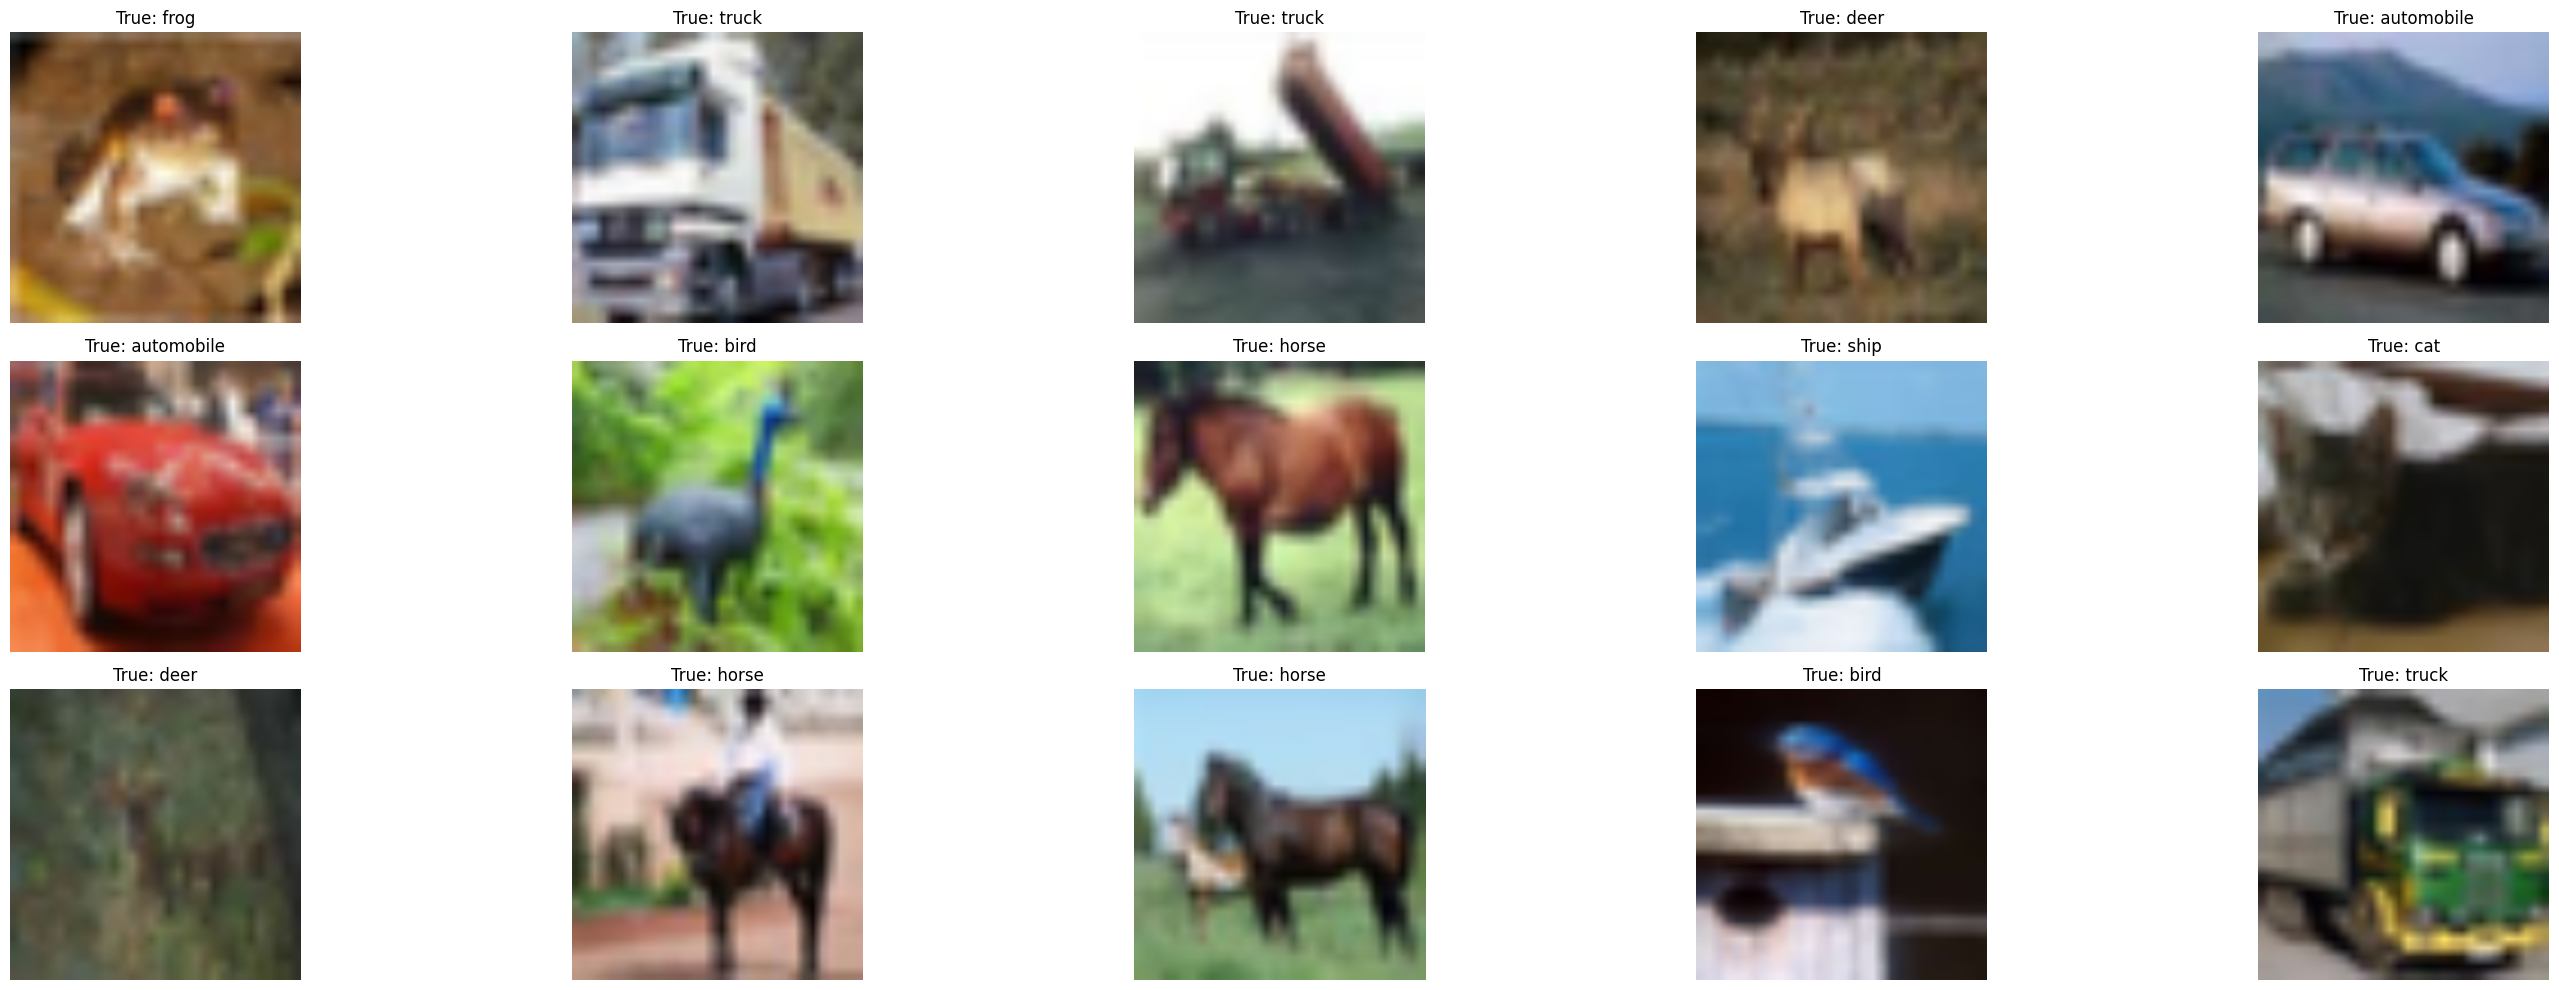

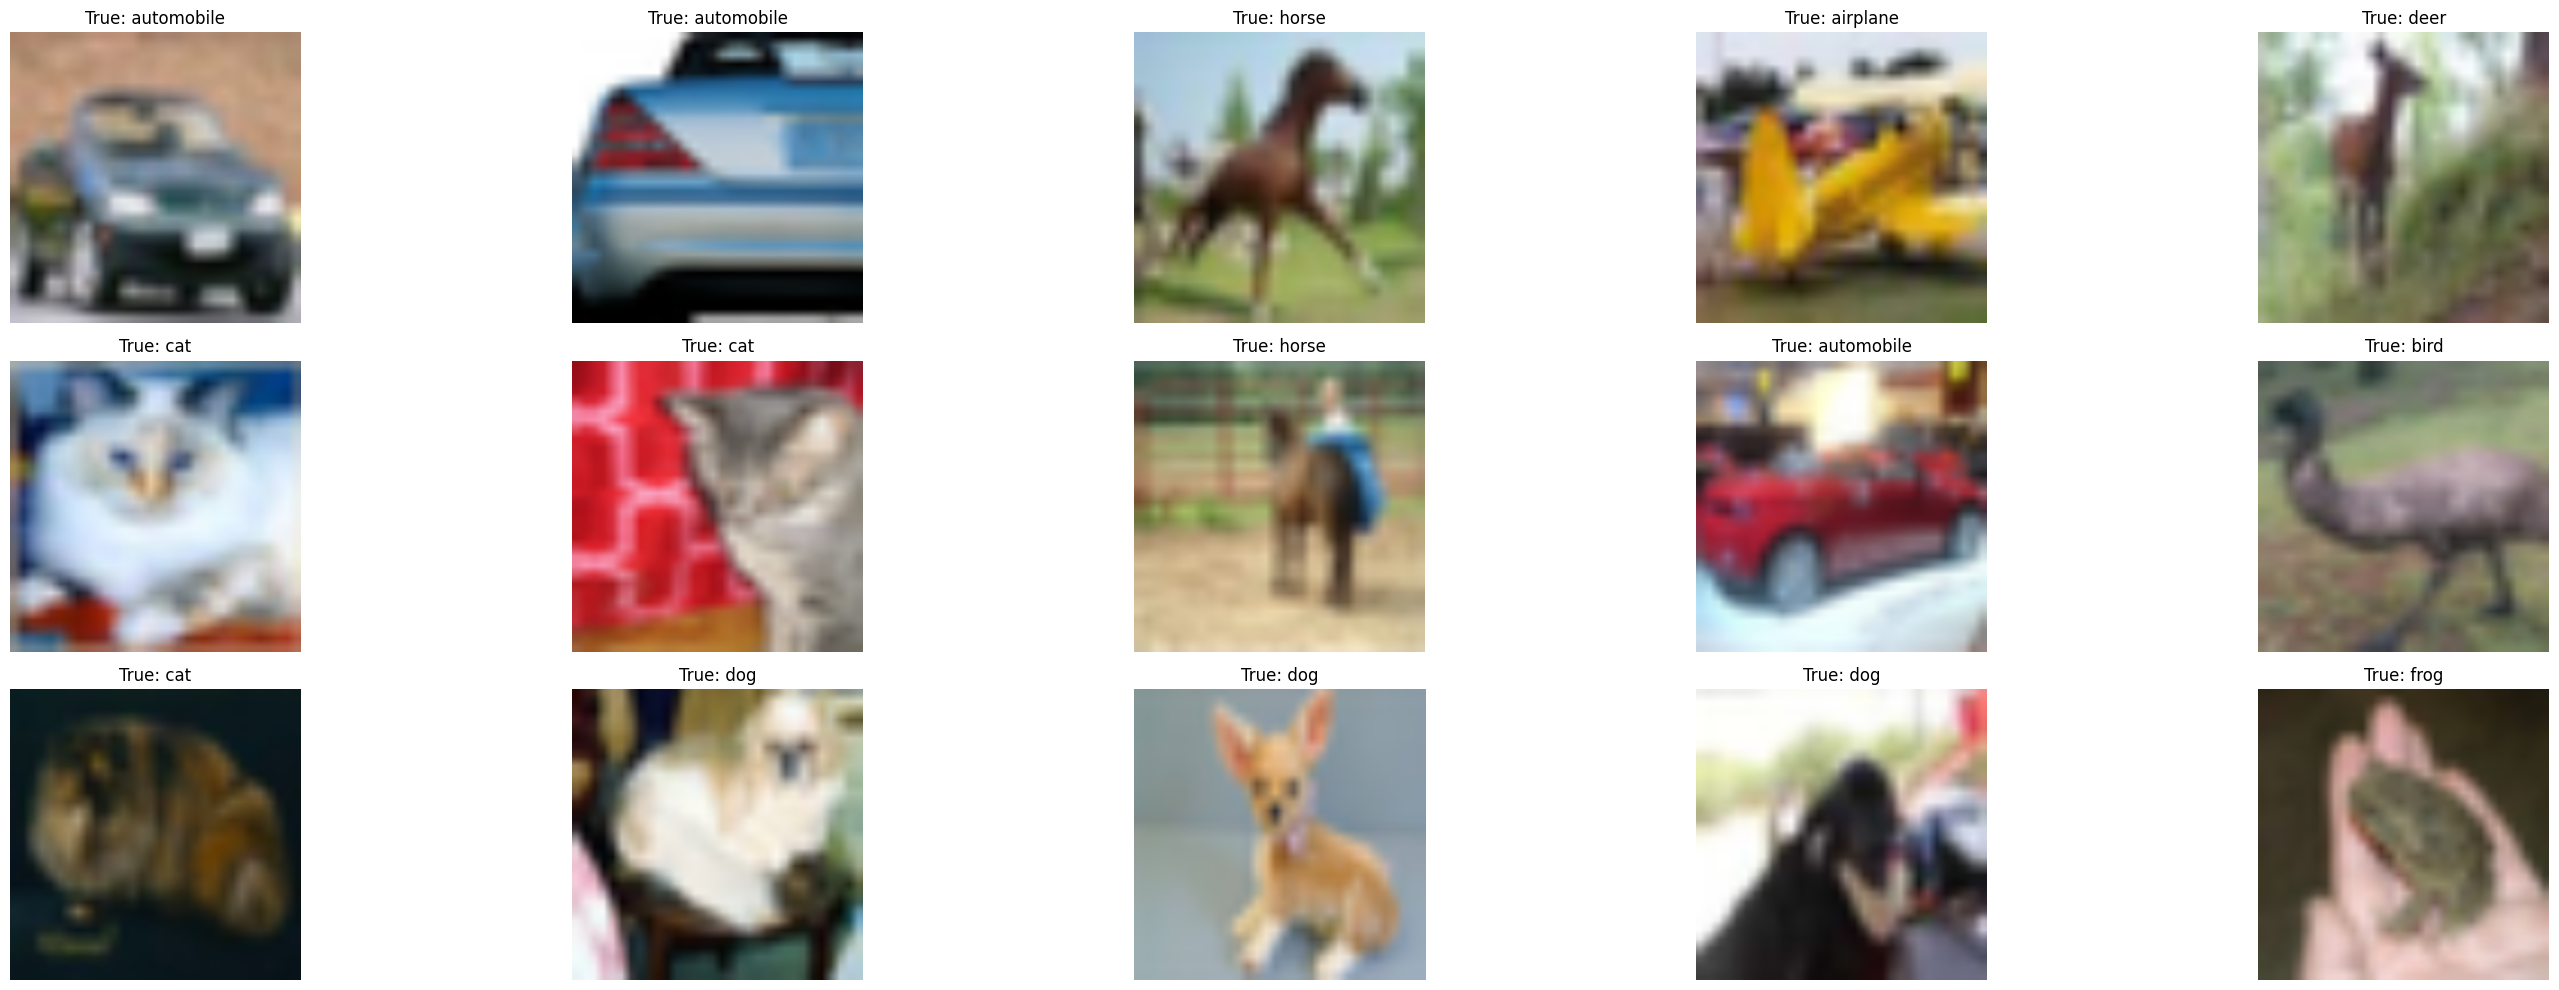

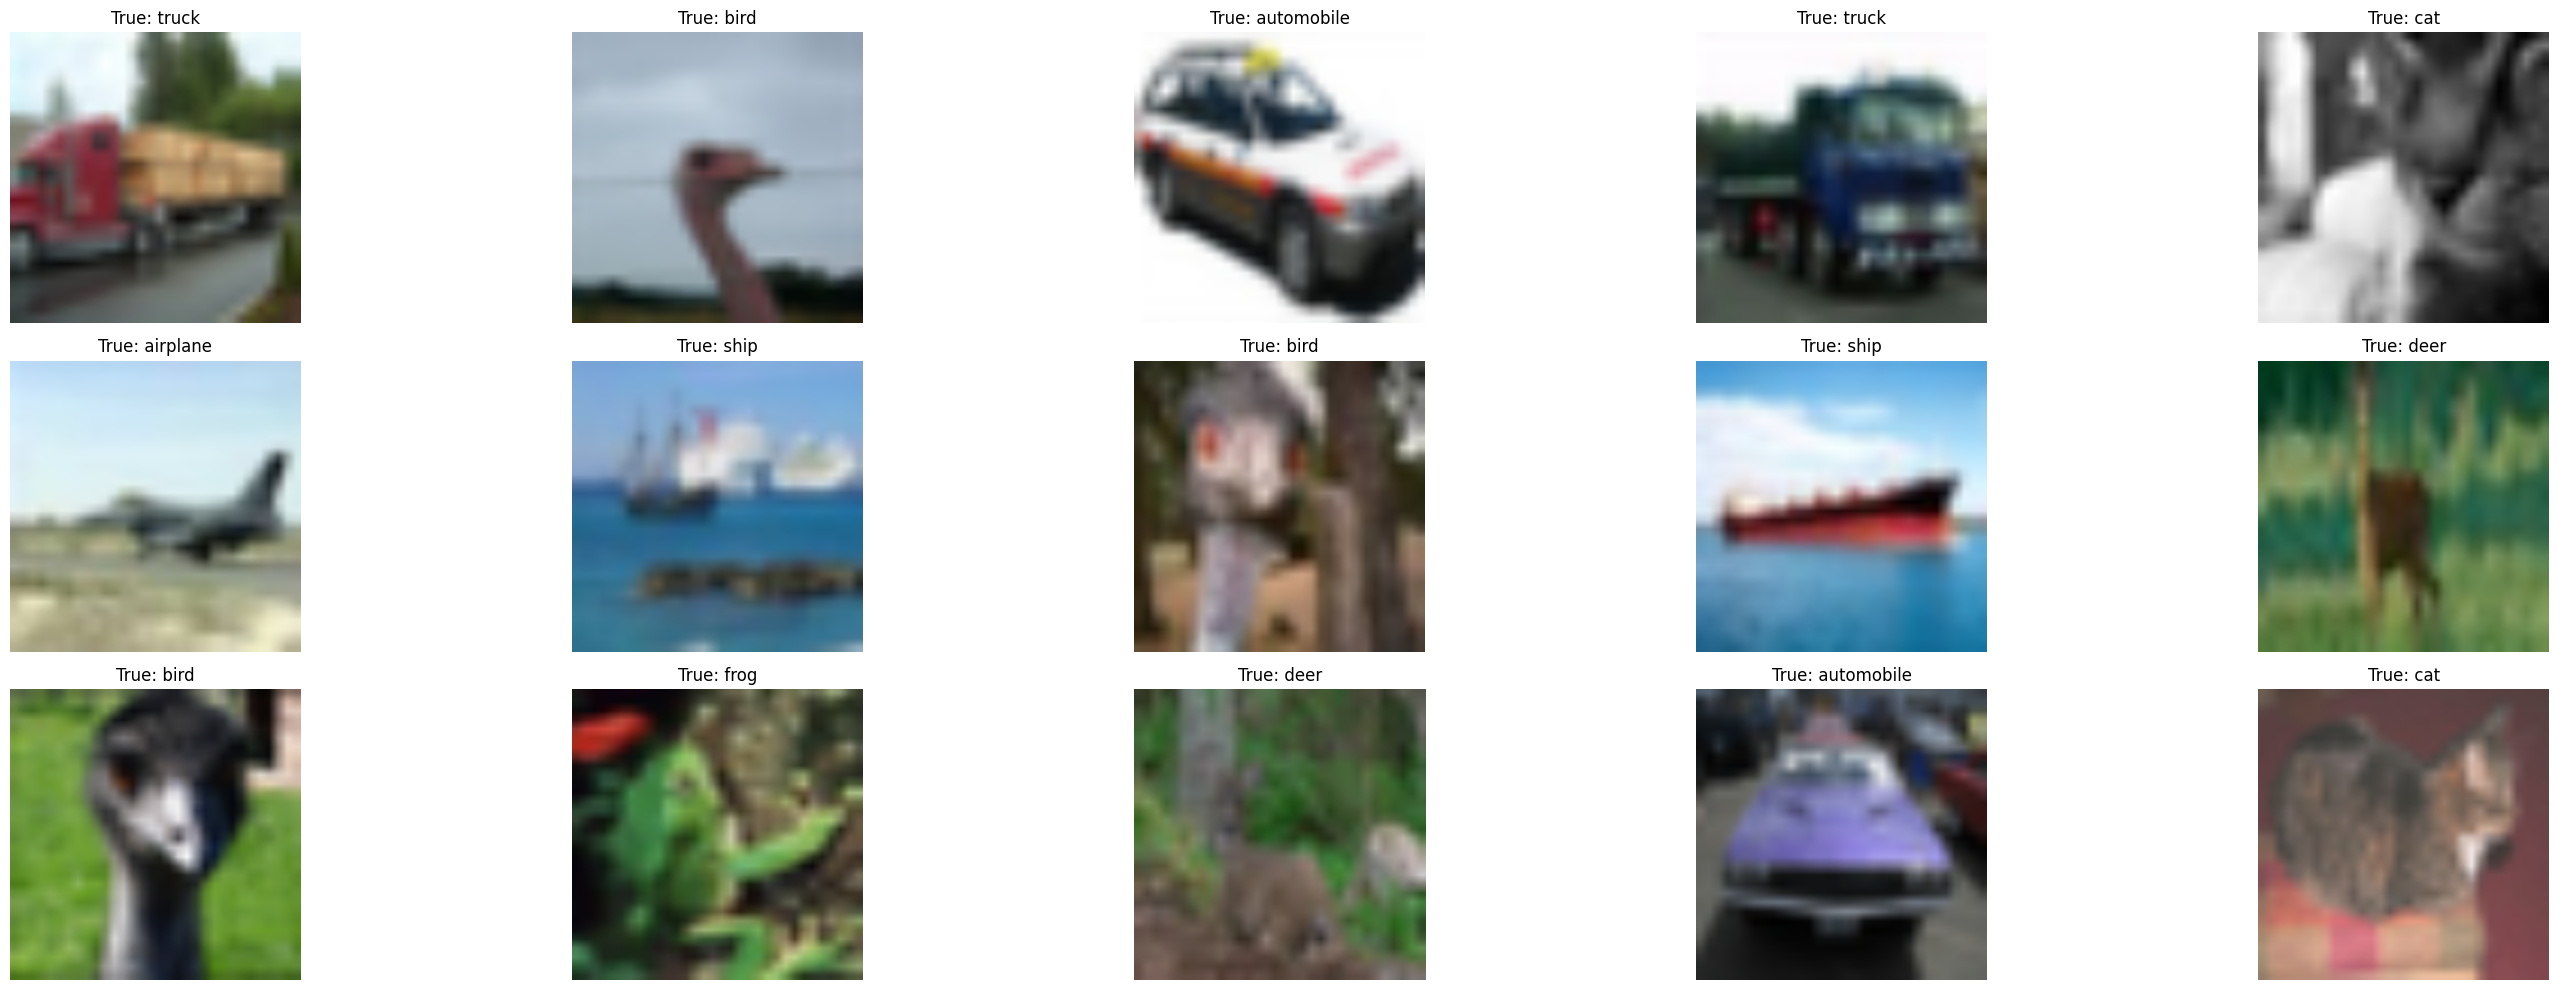

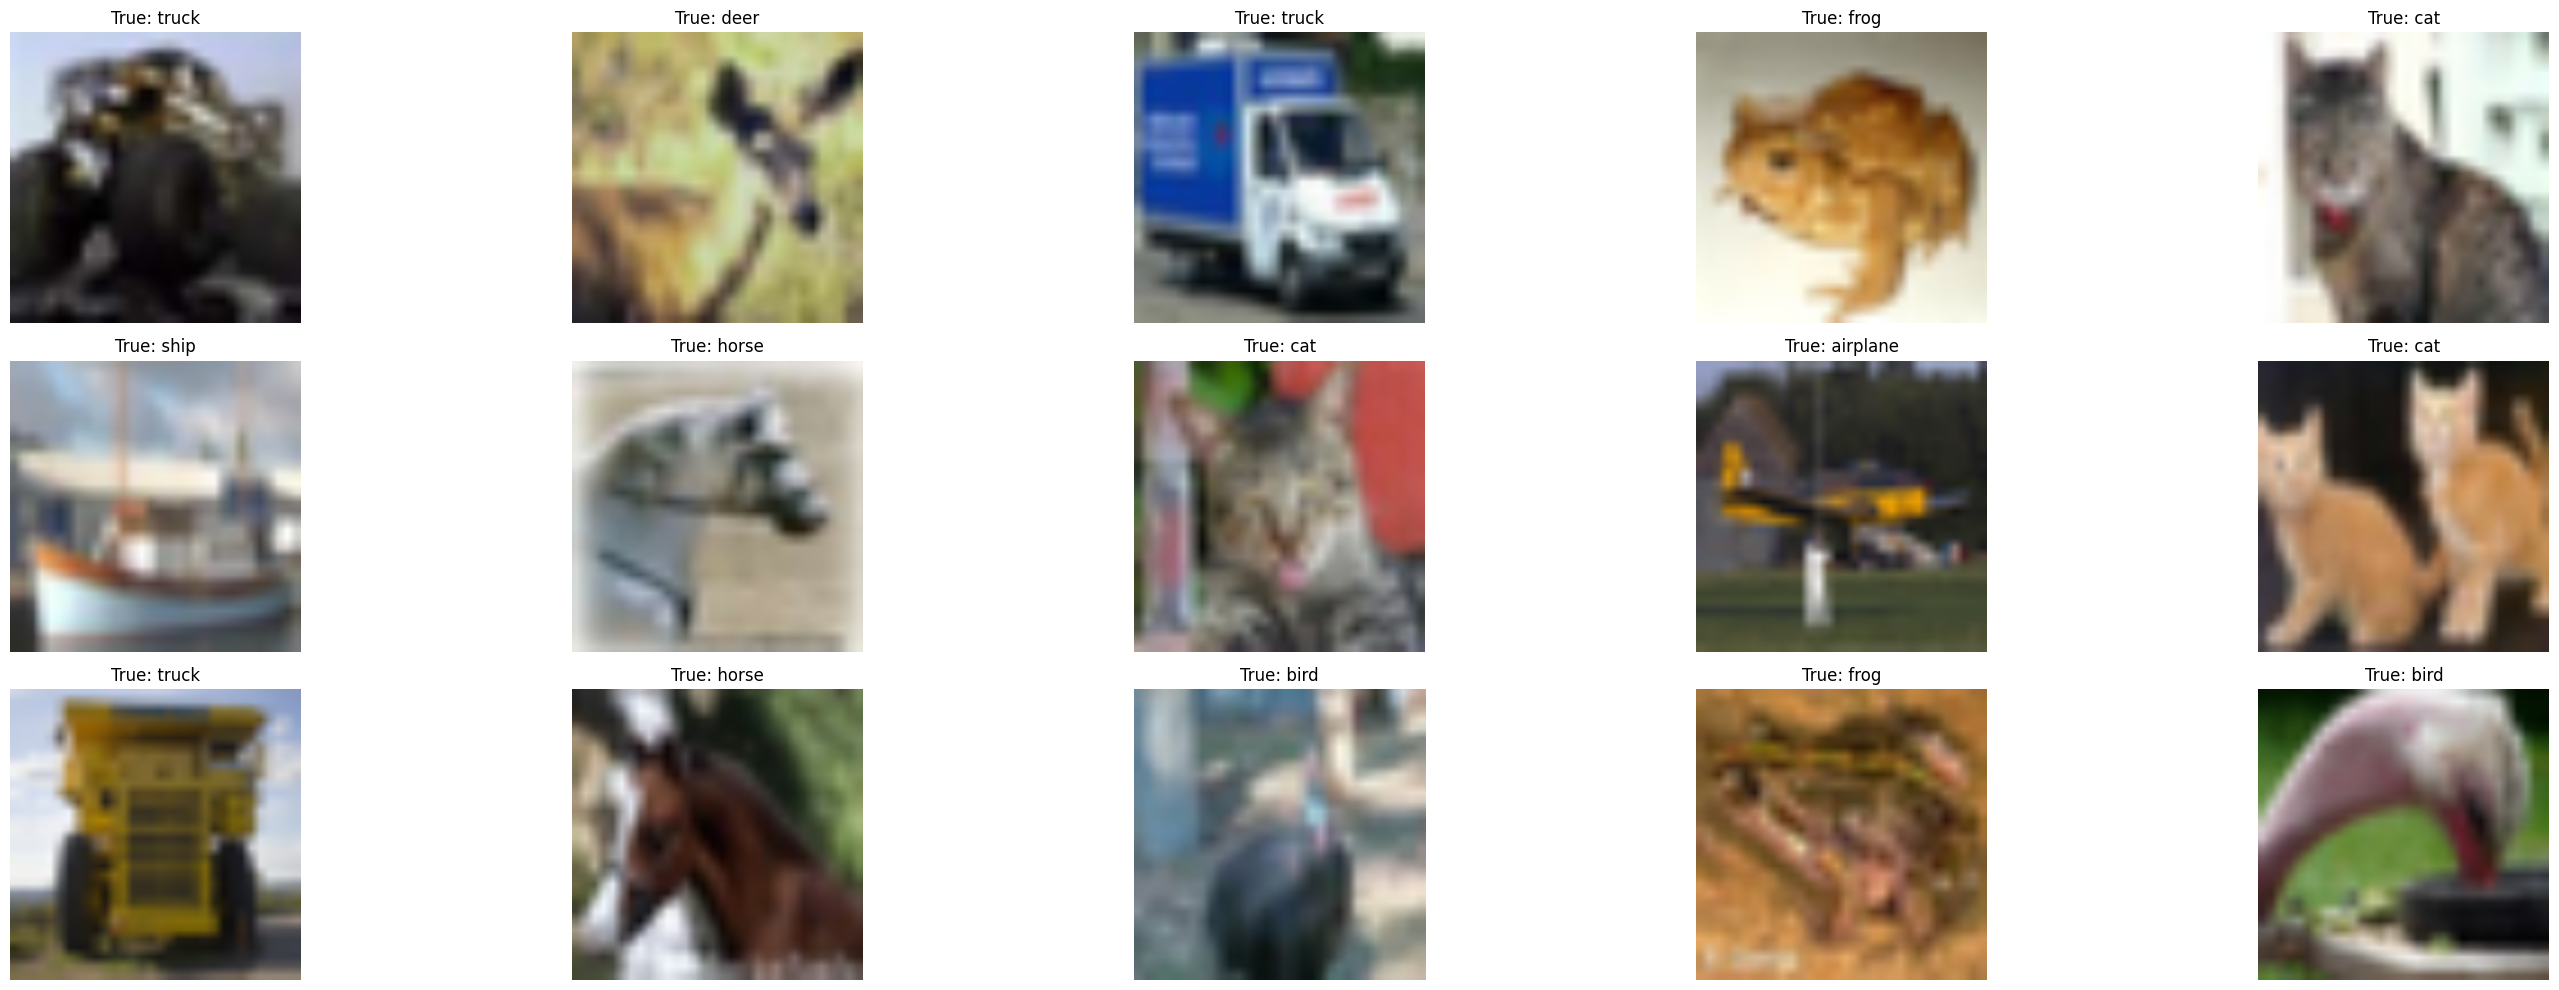

In [16]:
#First data exploration

trainset_defaultaug = trainset
trainset_defaultaug.transform = Transforms(default_preprocessing_pipeline)

for i in iterations:
    Helper.plot_images(trainset_defaultaug, trainset.classes, i)

del trainset_defaultaug

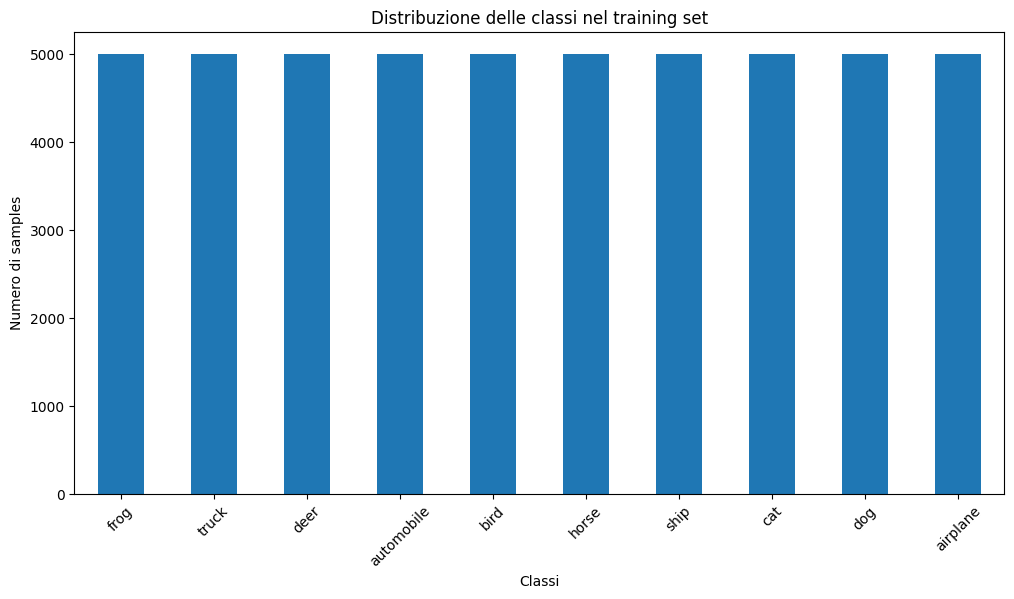

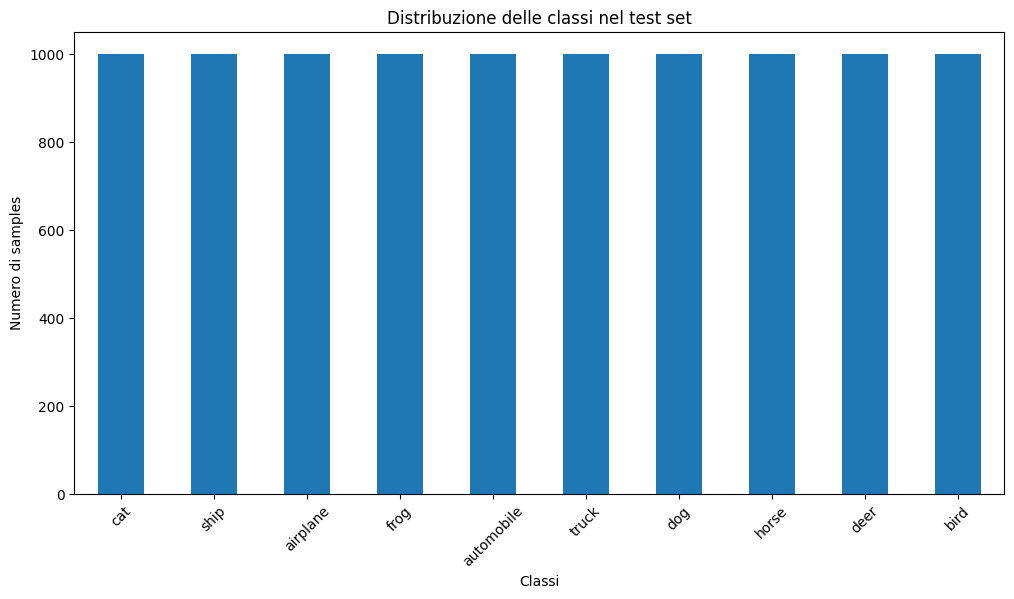

In [17]:
Helper.plot_class_distribution(trainset, type="training")
Helper.plot_class_distribution(testset, type="test")

## Reti